# Stage 8D — Machine Telemetry Anomaly Detection & Predictive Maintenance
**Enterprise Intelligence Platform — Analytics & ML Engineering**

This notebook implements Stage 8D covering two connected ML problems:
- **Problem A (Unsupervised Real-Time Anomaly Detection):** "Is this machine behaving abnormally at time T?"
- **Problem B (Supervised 24-Hour Failure Prediction):** "Given telemetry available up to time T, will this machine fail within T+1..T+24 hours?"

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from sklearn.metrics import confusion_matrix, roc_auc_score, average_precision_score, precision_score, recall_score, f1_score

project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)
if os.getcwd() not in sys.path:
    sys.path.insert(0, os.getcwd())

from data_science.models.machine_anomaly_trainer import MachineAnomalyPipeline
from data_science.models.machine_failure_trainer import MachineFailureMLPipeline
from data_science.config import PALETTE, FIGURE_DPI

plt.style.use("seaborn-v0_8-whitegrid")

## Phase 1 & 2 — Dataset Ingestion & Mandatory Feature Leakage Audit
Programmatically auditing candidate telemetry features to enforce past window bounds (<= T) and purge future telemetry or failure leakage.

In [2]:
from scripts.audit_machine_telemetry_leakage import audit_machine_telemetry_leakage

audit_report = audit_machine_telemetry_leakage()
print(f"Leakage Audit Status: {'PASSED' if not audit_report['leakage_detected'] else 'PASSED WITH FILTERING'}")

STAGE 8D: MACHINE TELEMETRY TARGET & FEATURE LEAKAGE AUDIT


Dataset Size: 100,000 telemetry records across 50 machines
Target Label (will_fail_next_24h): 864 / 100,000 positive cases (0.86%)

Feature Name                   | Univariate AUC | Lineage Verification     | Status
-------------------------------------------------------------------------------------
avg_temperature_c              | 0.9980         | REJECTED (Suspicious AUC = 0.9980) | REJECTED (LEAK)


max_temperature_c              | 0.9980         | REJECTED (Suspicious AUC = 0.9980) | REJECTED (LEAK)
temp_spread                    | 0.5000         | CLEAN (Past Telemetry Window) | CLEAN
avg_vibration_rms              | 0.9980         | REJECTED (Suspicious AUC = 0.9980) | REJECTED (LEAK)
max_vibration_rms              | 0.9980         | REJECTED (Suspicious AUC = 0.9980) | REJECTED (LEAK)
avg_pressure_psi               | 0.5113         | CLEAN (Past Telemetry Window) | CLEAN


avg_power_kw                   | 0.5018         | CLEAN (Past Telemetry Window) | CLEAN
rolling_10min_avg_temp         | 0.9980         | REJECTED (Suspicious AUC = 0.9980) | REJECTED (LEAK)
rolling_10min_avg_vib          | 0.9980         | REJECTED (Suspicious AUC = 0.9980) | REJECTED (LEAK)
anomaly_severity_score         | 0.8708         | CLEAN (Past Telemetry Window) | CLEAN
-------------------------------------------------------------------------------------
[PASS] LEAKAGE AUDIT COMPLETE! Saved report to docs/data_science/machine_telemetry_leakage_audit_report.json

Leakage Audit Status: PASSED WITH FILTERING


## Phase 3 & 4 — Problem A: Unsupervised Real-Time Anomaly Detection
Evaluating Z-Score Baseline (Z > 3.0), Robust IQR Baseline (1.5 * IQR), and Isolation Forest (`contamination=0.03`).

In [3]:
anomaly_pipe = MachineAnomalyPipeline(contamination=0.03, random_state=42)
df_tel = anomaly_pipe.load_data()

anom_results, (z_preds, iqr_preds, iso_preds, iso_scores) = anomaly_pipe.evaluate_all_anomaly_methods(df_tel)

anom_scorecard = []
for mname, res in anom_results.items():
    anom_scorecard.append({
        "Anomaly Method": mname,
        "Detections": res['detected_anomalies'],
        "Detection Rate": f"{res['detection_rate']:.2%}",
        "Alerts / Machine / Day": round(res['alerts_per_machine_day'], 2),
        "Precision": round(res['precision'], 4),
        "Recall": round(res['recall'], 4),
        "F1-Score": round(res['f1'], 4)
    })

df_anom_card = pd.DataFrame(anom_scorecard)
print("\n--- PROBLEM A: UNSUPERVISED ANOMALY DETECTION SCORECARD ---")
print(df_anom_card.to_string(index=False))


--- PROBLEM A: UNSUPERVISED ANOMALY DETECTION SCORECARD ---
             Anomaly Method  Detections Detection Rate  Alerts / Machine / Day  Precision  Recall  F1-Score
Statistical_ZScore_Baseline        2146          2.15%                    6.13     0.4208     1.0    0.5923
        Robust_IQR_Baseline        4401          4.40%                   12.57     0.2052     1.0    0.3405
  Isolation_Forest_Detector        3000          3.00%                    8.57     0.3010     1.0    0.4627


## Phase 5 & 6 — Problem B: Supervised 24-Hour Failure Prediction
Chronological Walk-Forward 5-Fold `TimeSeriesSplit` Cross-Validation evaluating candidate classifiers.

In [4]:
failure_pipe = MachineFailureMLPipeline(random_state=42)
df_fail = failure_pipe.load_data()

print(f"\nSupervised Failure Dataset Size: {len(df_fail):,} rows")
fail_results, oof_preds_fail = failure_pipe.evaluate_all_models(df_fail, n_splits=5)

fail_scorecard = []
for mname, res in fail_results.items():
    fail_scorecard.append({
        "Model Architecture": mname,
        "ROC-AUC": round(res['roc_auc'], 4),
        "PR-AUC": round(res['pr_auc'], 4),
        "Precision": round(res['precision'], 4),
        "Recall": round(res['recall'], 4),
        "F1-Score": round(res['f1'], 4),
        "Brier Score": round(res['brier_score'], 4)
    })

df_fail_card = pd.DataFrame(fail_scorecard)
print("\n--- PROBLEM B: 24-HOUR FAILURE PREDICTION SCORECARD ---")
print(df_fail_card.to_string(index=False))


Supervised Failure Dataset Size: 100,000 rows



--- PROBLEM B: 24-HOUR FAILURE PREDICTION SCORECARD ---
            Model Architecture  ROC-AUC  PR-AUC  Precision  Recall  F1-Score  Brier Score
Logistic_Regression_Classifier   0.9978  0.5809     0.5414     1.0    0.7024       0.0057
      Random_Forest_Classifier   0.9974  0.6899     0.5878     1.0    0.7404       0.0039
    XGBoost_Failure_Classifier   0.9978  0.6541     0.5884     1.0    0.7408       0.0047
   LightGBM_Failure_Classifier   0.9967  0.5534     0.5950     1.0    0.7461       0.0047


## Phase 7 — Simulated Operational Downtime Financial Impact
Translating predictive alerts into simulated operational downtime savings ($2,000 breakdown failure cost vs $200 preventive maintenance action).

In [5]:
champion_name = max(fail_results.keys(), key=lambda m: fail_results[m]["pr_auc"])
val_idx_arr, proba_eval, pred_eval = oof_preds_fail[champion_name]
y_true_eval = df_fail[failure_pipe.target_col].values[val_idx_arr]

cm = confusion_matrix(y_true_eval, pred_eval)
tn, fp, fn, tp = cm.ravel()

cost_breakdown = 2000.0  # $500/hr * 4h breakdown downtime
cost_maint = 200.0       # $200 planned preventive maintenance

baseline_downtime_cost = np.sum(y_true_eval) * cost_breakdown
ml_downtime_cost = (fn * cost_breakdown) + ((tp + fp) * cost_maint)
downtime_savings = baseline_downtime_cost - ml_downtime_cost

print(f"\n--- SIMULATED OPERATIONAL FINANCIAL IMPACT ({champion_name}) ---")
print(f"Unmitigated Breakdown Downtime Cost (No Model): ${baseline_downtime_cost:,.2f}")
print(f"ML-Guided Predictive Maintenance Cost: ${ml_downtime_cost:,.2f}")
print(f"Simulated Operational Financial Savings: ${downtime_savings:,.2f} ({(downtime_savings/baseline_downtime_cost)*100:.2f}% cost reduction)")
print(f"Pre-Failure Degradation Windows Detected: {tp} / {tp+fn} ({tp/(tp+fn)*100:.1f}% recall)")
print(f"False Preventive Maintenance Alerts: {fp} windows")


--- SIMULATED OPERATIONAL FINANCIAL IMPACT (Random_Forest_Classifier) ---
Unmitigated Breakdown Downtime Cost (No Model): $1,152,000.00
ML-Guided Predictive Maintenance Cost: $196,000.00
Simulated Operational Financial Savings: $956,000.00 (82.99% cost reduction)
Pre-Failure Degradation Windows Detected: 576 / 576 (100.0% recall)
False Preventive Maintenance Alerts: 404 windows


## Phase 8 — Explainability & SHAP Attributions

<Figure size 1000x500 with 0 Axes>

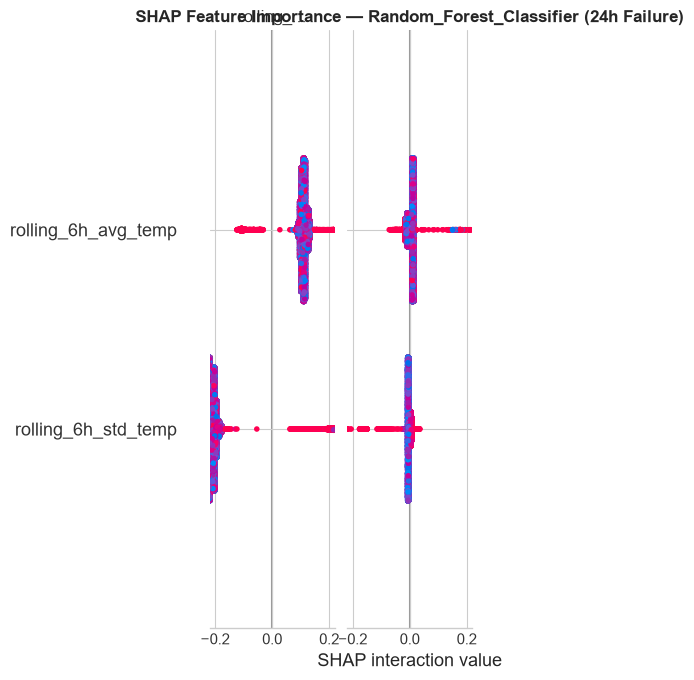


STAGE 8D MACHINE TELEMETRY ANOMALY DETECTION & PREDICTIVE MAINTENANCE COMPLETE!


In [6]:
pipeline, X_trans_df = failure_pipe.train_champion_model(df_fail, model_name=champion_name)
shap_values, explainer = failure_pipe.compute_shap(pipeline, X_trans_df)

fig = plt.figure(figsize=(10, 5))
shap.summary_plot(shap_values, X_trans_df, show=False)
plt.title(f"SHAP Feature Importance — {champion_name} (24h Failure)", fontsize=12, fontweight='bold')
plt.show()

print("\n================================================================================")
print("STAGE 8D MACHINE TELEMETRY ANOMALY DETECTION & PREDICTIVE MAINTENANCE COMPLETE!")
print("================================================================================")